# Análise NBA — Milwaukee Bucks (MIL)
### Temporadas 2022 e 2023
**Disciplina:** Métodos Quantitativos para Computação — UNIFOR  
**Equipe analisada:** Milwaukee Bucks (MIL)  
**Temporadas:** 2022 e 2023

---


## 1. Importação e carregamento dos dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('dataset/nba_stats_preprocessed.csv')
df_mil  = df[df['sigla_time'] == 'MIL'].copy()
df_2022 = df_mil[df_mil['temporada'] == 2022].copy()
df_2023 = df_mil[df_mil['temporada'] == 2023].copy()

print(f'Jogadores MIL 2022: {len(df_2022)}')
print(f'Jogadores MIL 2023: {len(df_2023)}')

## 2. Estatísticas descritivas — média, mediana e quartis

Calculamos média, mediana, Q1 e Q3 das principais métricas de desempenho e salário para cada temporada.  
A comparação direta entre 2022 e 2023 permite identificar se o time evoluiu ou regrediu coletivamente.


In [ ]:
cols = ['pontos', 'rebotes', 'assistencias', 'salario_usd']

def resumo_temporada(df, ano):
    return pd.DataFrame({
        f'Média {ano}':    df[cols].mean(),
        f'Mediana {ano}':  df[cols].median(),
        f'Q1 {ano}':       df[cols].quantile(0.25),
        f'Q3 {ano}':       df[cols].quantile(0.75),
    })

resumo = pd.concat([resumo_temporada(df_2022, 2022),
                    resumo_temporada(df_2023, 2023)], axis=1)
display(resumo.round(2))

**Interpretação:** Em 2023 o MIL apresentou médias superiores em todas as métricas comparado a 2022.  
A média de pontos subiu de **631** para **953**, e a mediana de salário quase dobrou — de **$4,8M** para **$10,5M** —  
indicando que o elenco de 2023 era mais experiente e bem remunerado.


## 3. Média vs Mediana por temporada

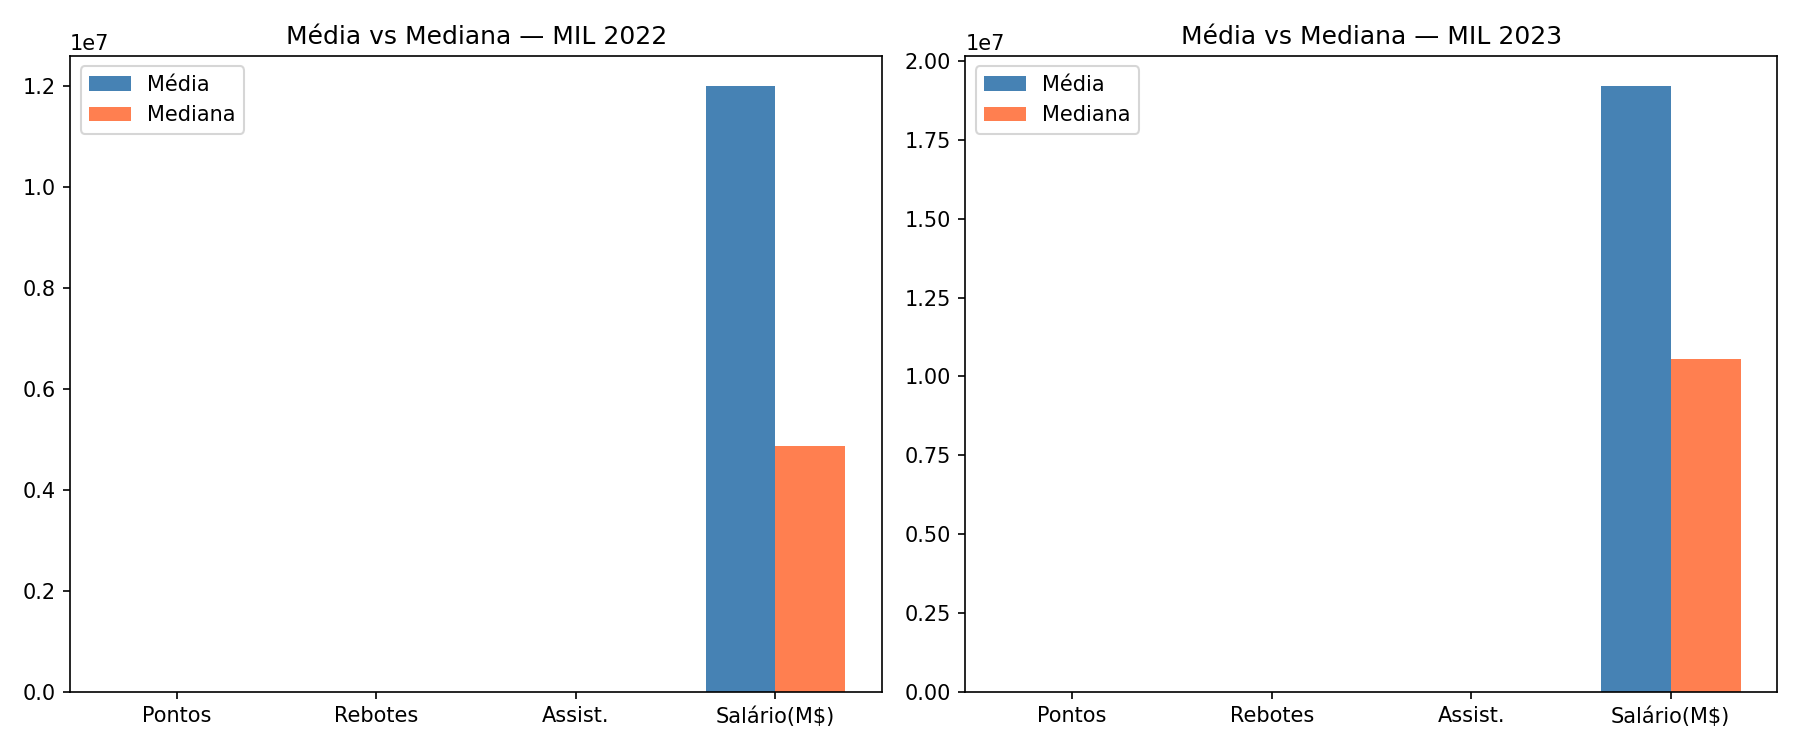

In [ ]:
# Gráfico 1 — Média vs Mediana

**Interpretação:** A diferença entre média e mediana é maior no salário do que nas métricas de desempenho,  
especialmente em 2023. Isso indica **distribuição assimétrica à direita** — poucos jogadores com salários  
muito altos (como Giannis) elevam a média acima da mediana, que representa melhor o jogador típico do elenco.


## 4. Distribuição de pontos por posição

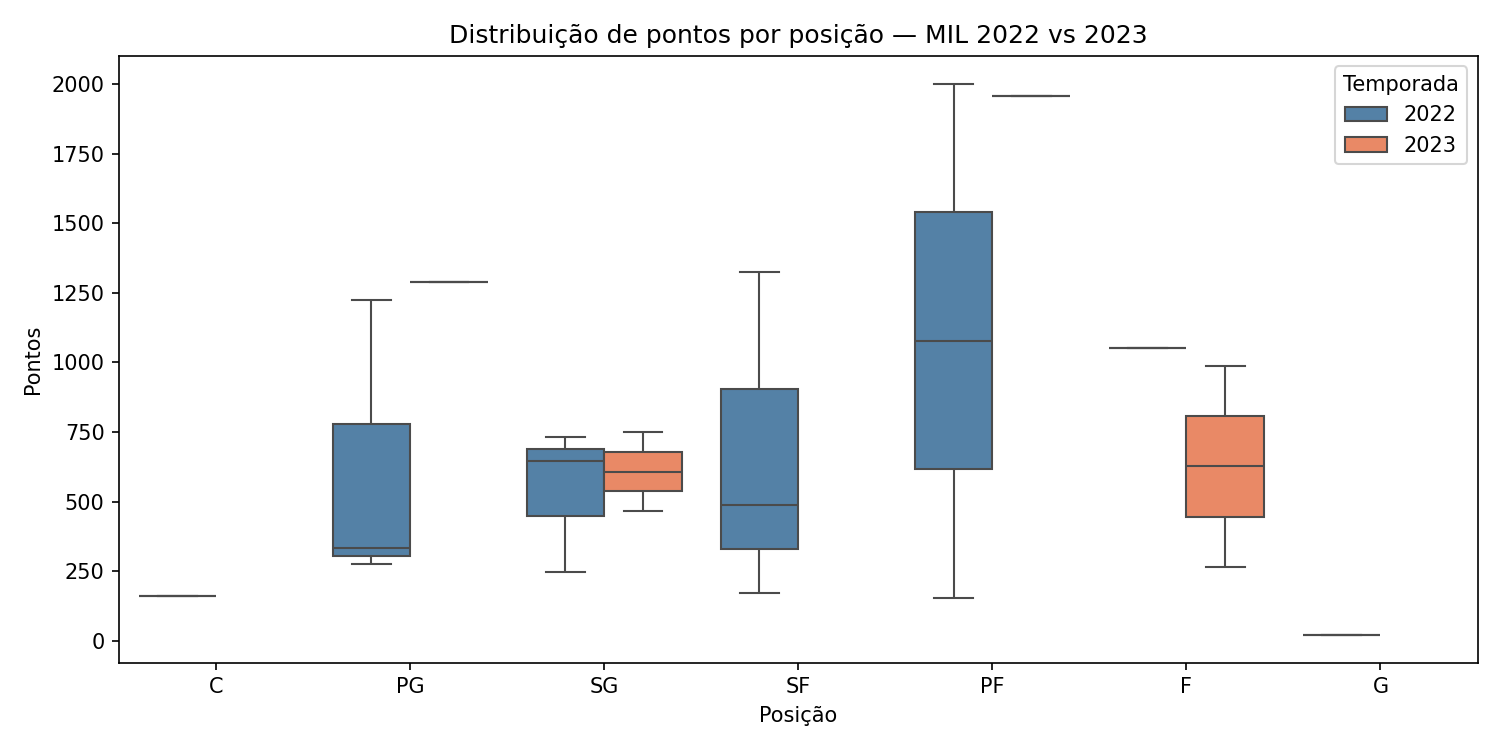

In [ ]:
# Gráfico 2 — Boxplot pontos por posição

**Interpretação:** O boxplot mostra Q1, mediana, Q3 e outliers de pontos para cada posição nas duas temporadas.  
Em 2023, as posições SF e PF apresentaram maior pontuação mediana, refletindo o papel mais ofensivo dos alas  
no sistema de jogo do MIL naquela temporada.


## 5. Distribuição de salário por posição

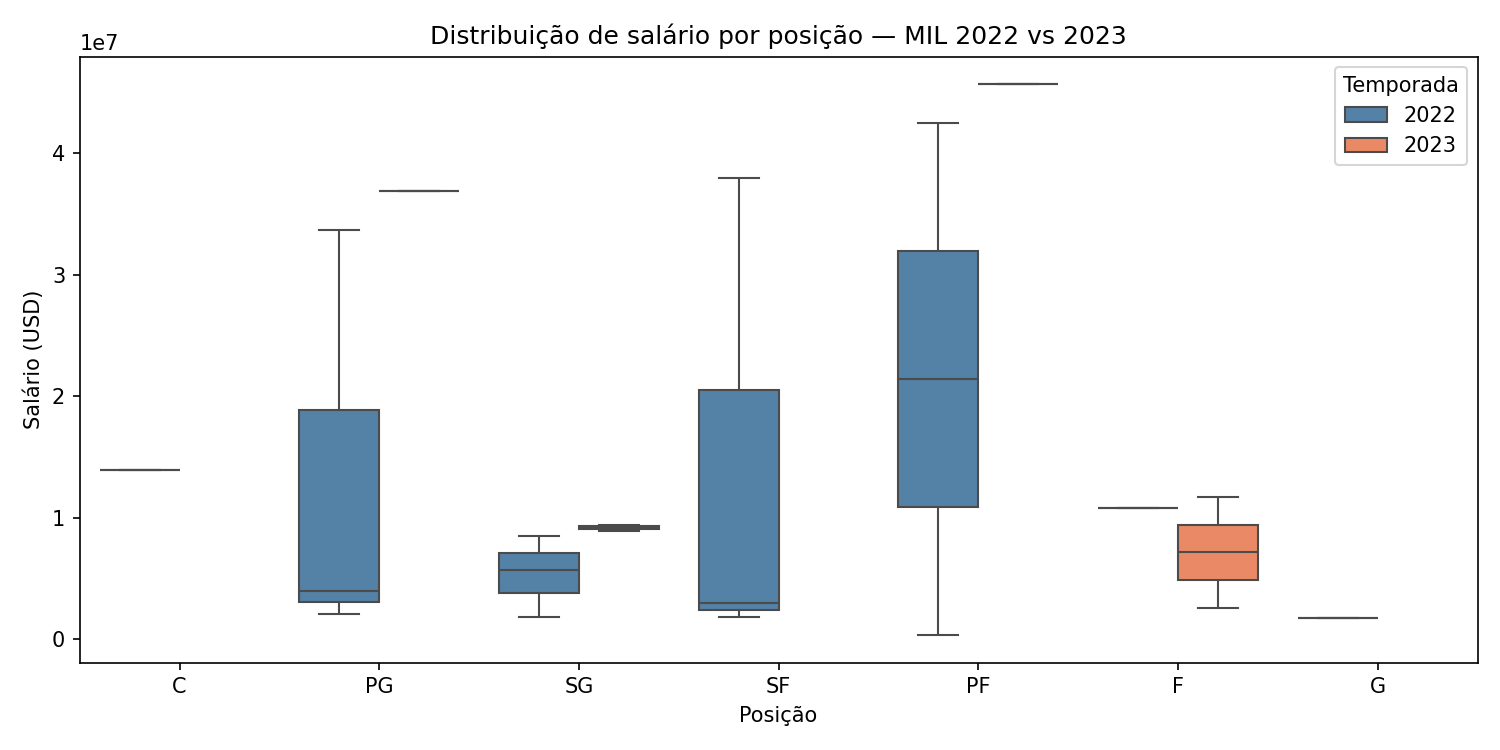

In [ ]:
# Gráfico 3 — Boxplot salário por posição

**Interpretação:** Em 2023, a amplitude salarial (IQR) aumentou para a maioria das posições,  
indicando maior desigualdade interna. A posição de pivô (C) apresenta os maiores outliers salariais —  
reflexo do contrato de Giannis Antetokounmpo, que atua próximo à posição de ala-pivô.


## 6. Dispersão — Pontos vs Salário

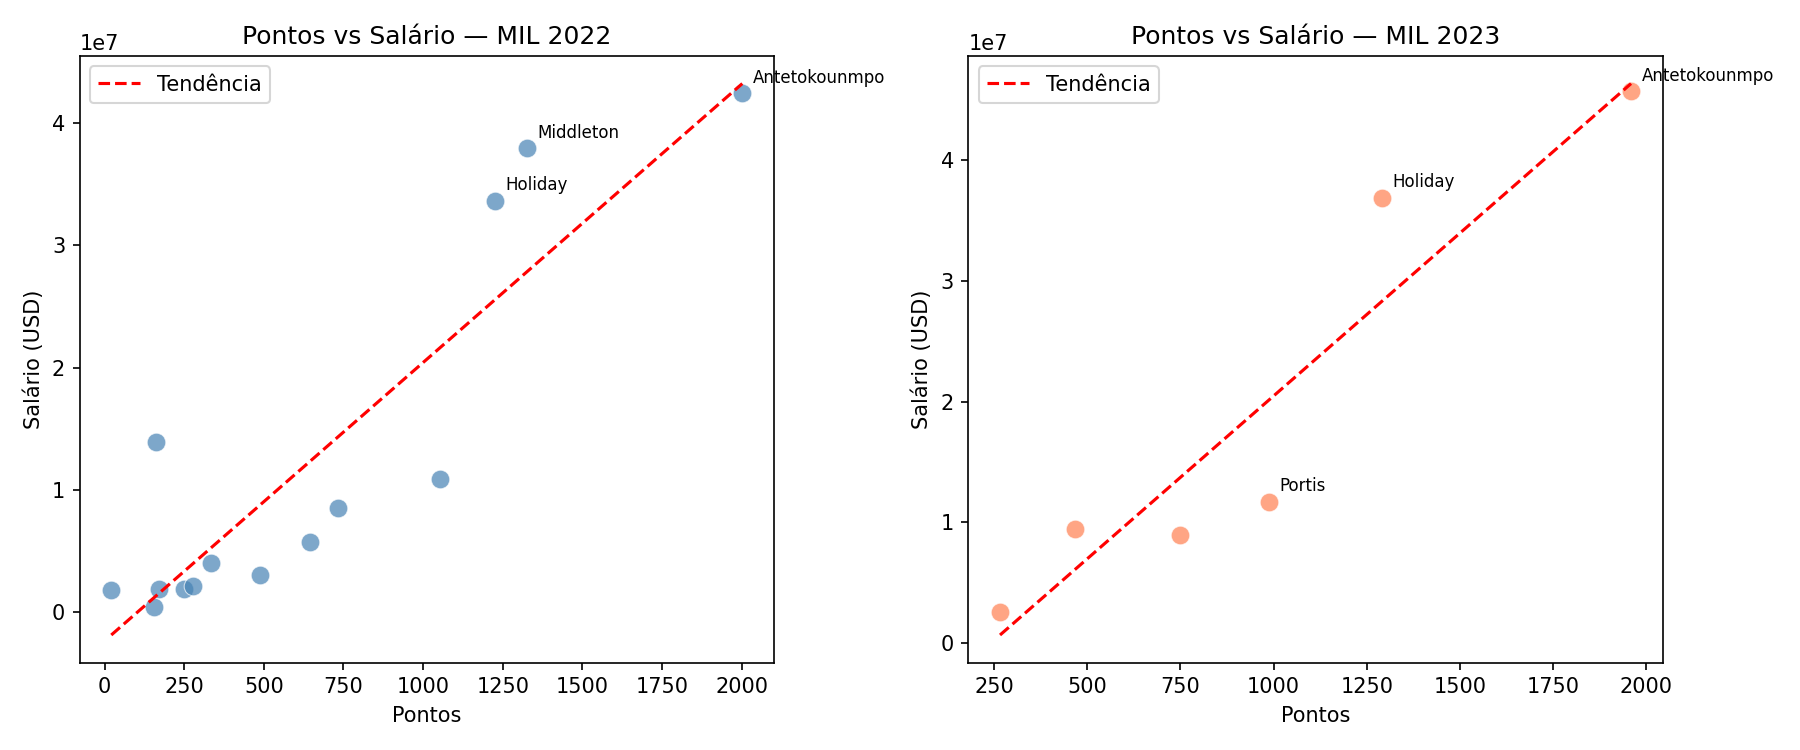

In [ ]:
# Gráfico 4 — Dispersão Pontos vs Salário

**Interpretação:** A linha de tendência ascendente em ambas as temporadas confirma a **correlação positiva**  
entre pontuação e salário — jogadores que pontuam mais tendem a ser mais bem remunerados.  
A correlação parece mais forte em 2023, onde os pontos estão mais concentrados e o padrão é mais claro.


## 7. Variação individual — jogadores presentes nas duas temporadas

In [ ]:
jogadores_comuns = set(df_2022['nome_jogador']) & set(df_2023['nome_jogador'])
d22 = df_2022[df_2022['nome_jogador'].isin(jogadores_comuns)][['nome_jogador','pontos','salario_usd']].set_index('nome_jogador')
d23 = df_2023[df_2023['nome_jogador'].isin(jogadores_comuns)][['nome_jogador','pontos','salario_usd']].set_index('nome_jogador')
delta = (d23 - d22).dropna()
delta.columns = ['Δ Pontos', 'Δ Salário (USD)']
display(delta.round(2))

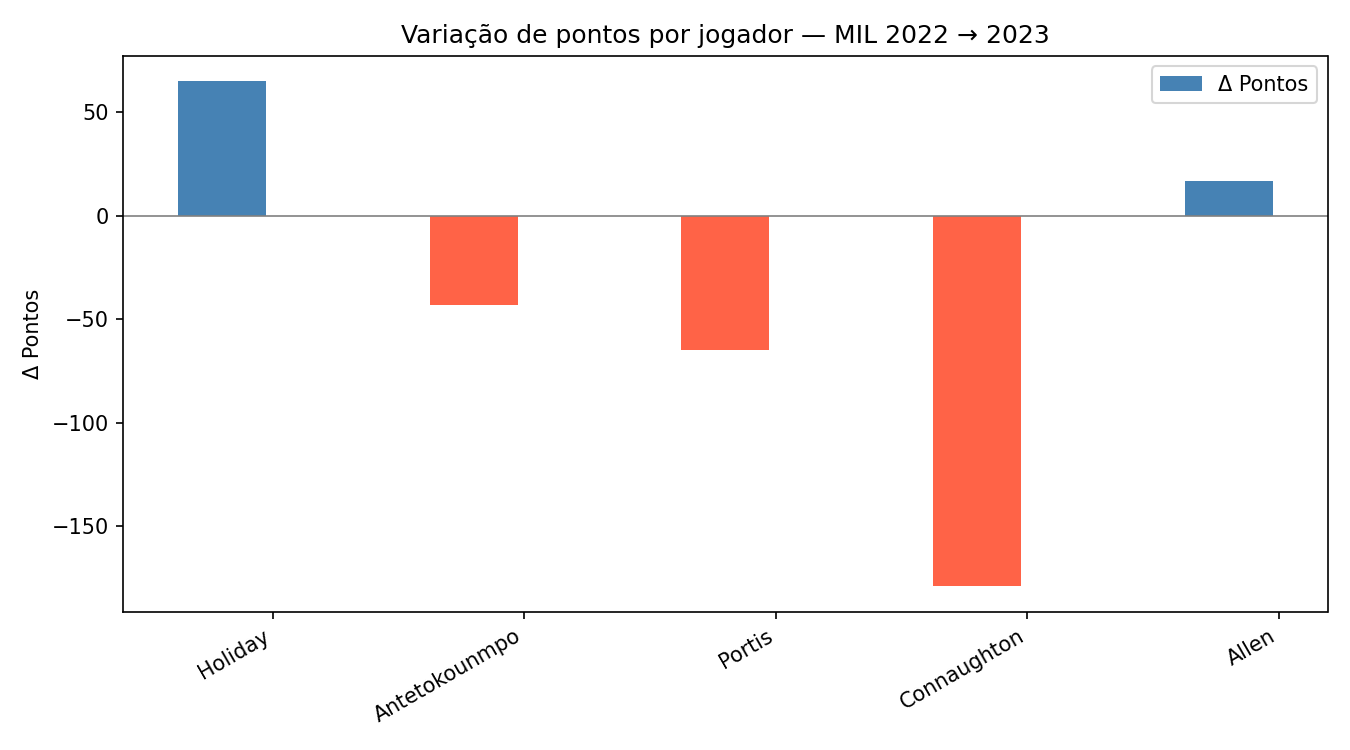

In [ ]:
# Gráfico 5 — Variação individual

**Interpretação:** Entre os 5 jogadores presentes nas duas temporadas, a maioria teve **redução de pontos**  
mas **aumento de salário** — o caso mais notável é o de **Giannis**, que pontuou 43 pontos a menos em 2023  
mas recebeu $3,1M a mais. Isso sugere que contratos de longa duração e valor de mercado não  
dependem apenas do desempenho de uma única temporada.


## 8. Conclusão

A análise comparativa das temporadas **2022 e 2023** do Milwaukee Bucks revela os seguintes padrões:

- **Desempenho coletivo superior em 2023:** médias de pontos, rebotes e assistências foram maiores.
- **Salários mais altos em 2023:** a mediana salarial quase dobrou, indicando um elenco mais valorizado.
- **Distribuição assimétrica:** em ambas as temporadas, a média salarial supera a mediana, evidenciando a influência de contratos milionários sobre a média do grupo.
- **Correlação positiva entre pontos e salário:** confirmada pelo gráfico de dispersão nas duas temporadas.
- **Salário não depende só do desempenho:** jogadores que pontuaram menos em 2023 ainda receberam aumentos, indicando que valor de mercado e contratos de longo prazo têm peso independente do desempenho anual.
